In [10]:
import subprocess
import os
import shutil

# Define dataset path
dataset_path = "./shapes_dataset"

# Paths for images and annotations
images_dir = os.path.join(dataset_path, "images")
annotations_dir = os.path.join(dataset_path, "annotations")

# Clear the directories before generating new files
if os.path.exists(images_dir):
    shutil.rmtree(images_dir)
    print(f"✅ Cleared old images from: {images_dir}")
else:
    print(f"⚠️ No existing images directory found at: {images_dir}")

if os.path.exists(annotations_dir):
    shutil.rmtree(annotations_dir)
    print(f"✅ Cleared old annotations from: {annotations_dir}")
else:
    print(f"⚠️ No existing annotations directory found at: {annotations_dir}")

# Recreate the directories
os.makedirs(images_dir)
os.makedirs(annotations_dir)
print(f"✅ Created new directories for images and annotations at: {dataset_path}")

# Set dynamic parameters
num_images = 5  # Change this dynamically if needed
image_width = 128  # Change this dynamically if needed
image_height = 128  # Change this dynamically if needed

# Run the dataset generation script inside Jupyter
command = [
    "python", "shapes/run.py",
    "--save_dir", dataset_path,
    "--num_images", str(num_images),
    "--image_size", str(image_width), str(image_height),  # ✅ Explicitly setting image size dynamically
    "--task_type", "segmentation"
]

# Execute the command
result = subprocess.run(command, capture_output=True, text=True)
print(result.stdout)  # Print output for debugging

# Check if dataset is created
coco_annotations_file = os.path.join(annotations_dir, "coco_annotations.json")

if not os.path.exists(coco_annotations_file):
    print("❌ ERROR: Dataset not generated correctly! Check run.py.")
else:
    print(f"✅ Shapes dataset successfully generated with {num_images} images of size {image_width}x{image_height}!")
    print(f"Images are saved in: {images_dir}")
    print(f"Annotations are saved in: {annotations_dir}")
    print(f"COCO annotations file: {coco_annotations_file}")

✅ Cleared old images from: ./shapes_dataset/images
✅ Cleared old annotations from: ./shapes_dataset/annotations
✅ Created new directories for images and annotations at: ./shapes_dataset
✅ Dataset and COCO annotations saved to ./shapes_dataset

✅ Shapes dataset successfully generated with 5 images of size 128x128!
Images are saved in: ./shapes_dataset/images
Annotations are saved in: ./shapes_dataset/annotations
COCO annotations file: ./shapes_dataset/annotations/coco_annotations.json


In [12]:
#Step 2: Load and Verify COCO Annotations
import json

# Define the correct path for the COCO annotations file
OUTPUT_ANNOTATION_FILE = "./shapes_dataset/annotations/coco_annotations.json"

# Verify COCO Annotations
try:
    with open(OUTPUT_ANNOTATION_FILE, "r") as f:
        coco_data = json.load(f)
        # Debugging: Loop over annotations and extract bounding boxes
    for ann in coco_data["annotations"]:
        x, y, w, h = map(int, ann["bbox"])  # Extract coordinates and size
        print(f"🖼 Object | BBox: ({x}, {y}, {x+w}, {y+h}) | Size: ({w}x{h})")


    # Show structure
    print("✅ COCO Annotations Loaded Successfully!")
    print(json.dumps(coco_data, indent=4)[:1000])  # Print first 1000 characters

except FileNotFoundError:
    print(f"❌ ERROR: The file {OUTPUT_ANNOTATION_FILE} was not found. Make sure it was generated correctly!")

🖼 Object | BBox: (79, 98, 94, 113) | Size: (15x15)
🖼 Object | BBox: (48, 89, 76, 117) | Size: (28x28)
🖼 Object | BBox: (71, 22, 101, 52) | Size: (30x30)
🖼 Object | BBox: (14, 13, 50, 49) | Size: (36x36)
🖼 Object | BBox: (72, -6, 118, 40) | Size: (46x46)
🖼 Object | BBox: (79, 63, 93, 77) | Size: (14x14)
🖼 Object | BBox: (25, 33, 61, 69) | Size: (36x36)
🖼 Object | BBox: (106, 78, 118, 90) | Size: (12x12)
✅ COCO Annotations Loaded Successfully!
{
    "images": [
        {
            "id": 0,
            "width": 128,
            "height": 128,
            "file_name": "shapes_0.png"
        },
        {
            "id": 1,
            "width": 128,
            "height": 128,
            "file_name": "shapes_1.png"
        },
        {
            "id": 2,
            "width": 128,
            "height": 128,
            "file_name": "shapes_2.png"
        },
        {
            "id": 3,
            "width": 128,
            "height": 128,
            "file_name": "shapes_3.png"
       

✅ Checkpoint already exists at: /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth
✅ Loaded COCO annotations from ./shapes_dataset/annotations/coco_annotations.json
🔹 Total Images: 5 | Total Annotations: 7
📌 Loaded shapes_0.png | Image Size: (98, 99) (Height, Width)
🔹 Resized Image Size (if resizing was applied): (98, 99) (Height, Width)
🛠 Input Box for SAM: [42 39 61 58]
✅ 3 masks detected.


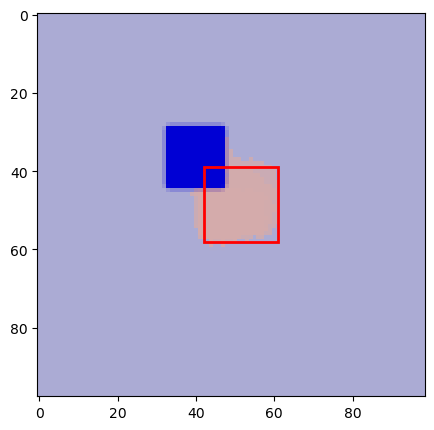

📌 Loaded shapes_1.png | Image Size: (98, 99) (Height, Width)
🔹 Resized Image Size (if resizing was applied): (98, 99) (Height, Width)
🛠 Input Box for SAM: [15 14 45 44]
✅ 3 masks detected.
🛠 Input Box for SAM: [122  26 141  45]
✅ 3 masks detected.


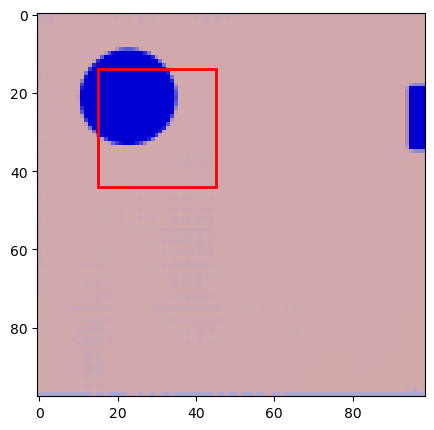

📌 Loaded shapes_2.png | Image Size: (98, 99) (Height, Width)
🔹 Resized Image Size (if resizing was applied): (98, 99) (Height, Width)
🛠 Input Box for SAM: [58  6 86 34]
✅ 3 masks detected.


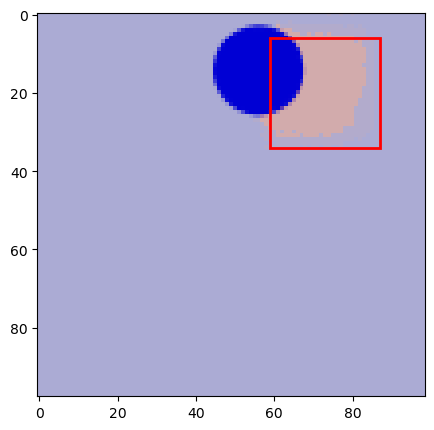

📌 Loaded shapes_3.png | Image Size: (98, 99) (Height, Width)
🔹 Resized Image Size (if resizing was applied): (98, 99) (Height, Width)
🛠 Input Box for SAM: [72 35 87 50]
✅ 3 masks detected.


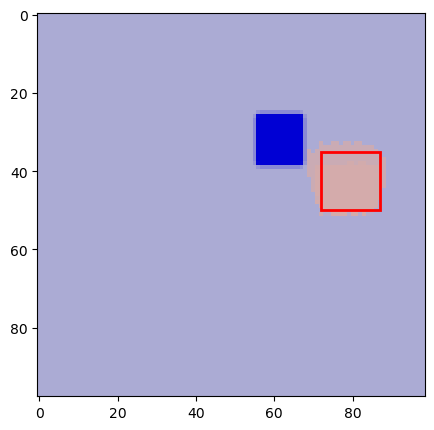

📌 Loaded shapes_4.png | Image Size: (98, 99) (Height, Width)
🔹 Resized Image Size (if resizing was applied): (98, 99) (Height, Width)
🛠 Input Box for SAM: [30 65 43 78]
✅ 3 masks detected.
🛠 Input Box for SAM: [-8  3 32 43]
✅ 3 masks detected.


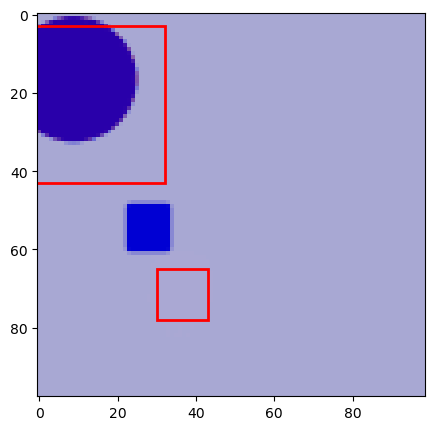


✅ SAM Masks Generated and Saved in COCO Format!
🔹 Total Images Processed: 5 | Masks Generated: 21 | No Masks: 0

🔹 Full Summary of Results:

📌 shapes_0.png - Before and After Processing:
   🔹 Before Processing - Size: (99, 98)
   🔹 After Processing - Size: (99, 98)
   🔹 Masks Detected: 3
   🔹 Masks Generated: 3
   🔹 No Masks Found: 0

📌 shapes_1.png - Before and After Processing:
   🔹 Before Processing - Size: (99, 98)
   🔹 After Processing - Size: (99, 98)
   🔹 Masks Detected: 6
   🔹 Masks Generated: 6
   🔹 No Masks Found: 0

📌 shapes_2.png - Before and After Processing:
   🔹 Before Processing - Size: (99, 98)
   🔹 After Processing - Size: (99, 98)
   🔹 Masks Detected: 3
   🔹 Masks Generated: 3
   🔹 No Masks Found: 0

📌 shapes_3.png - Before and After Processing:
   🔹 Before Processing - Size: (99, 98)
   🔹 After Processing - Size: (99, 98)
   🔹 Masks Detected: 3
   🔹 Masks Generated: 3
   🔹 No Masks Found: 0

📌 shapes_4.png - Before and After Processing:
   🔹 Before Processing - Siz

In [6]:
# Step 3: Load SAM Model & Process COCO Annotations with Visualization
import os
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model with Debugging
# ============================

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create directory if needed
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Download checkpoint if not exists
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

# Load SAM model
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations with Debugging
# ============================

DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_with_masks.json")

# Check if annotation file exists
if not os.path.exists(ANNOTATION_FILE):
    print(f"❌ ERROR: COCO annotation file not found: {ANNOTATION_FILE}")
    raise FileNotFoundError(f"COCO annotation file {ANNOTATION_FILE} does not exist!")

# Load COCO JSON
with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# Debug: Check if images exist
if len(coco_data["images"]) == 0:
    print("⚠️ WARNING: No images found in COCO annotations! Check dataset generation.")
    raise ValueError("COCO dataset has no images!")

# Debug: Check if annotations exist
if len(coco_data["annotations"]) == 0:
    print("⚠️ WARNING: No annotations found in COCO annotations! Expected bounding boxes.")
    raise ValueError("COCO dataset has no annotations!")

# ============================
# 🔹 Run SAM on Each Image & Generate Masks (with Normalization & Visualization)
# ============================

new_annotations = []
masks_generated = 0
no_masks_found = 0

# For final summary of results
image_summary = []

for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    # Check if image exists
    if not os.path.exists(img_path):
        print(f"⚠️ Skipping: {img_info['file_name']} (File Not Found)")
        continue

    # Load image
    image = cv2.imread(img_path)
    
    # Debugging: Print image size after loading
    original_img_width, original_img_height = image.shape[1], image.shape[0]
    print(f"📌 Loaded {img_info['file_name']} | Image Size: {image.shape[:2]} (Height, Width)")

    # Optional: Resize the image if you want to see if it's being resized here
    # image = cv2.resize(image, (128, 128))  # Uncomment if you want to resize explicitly
    # Debugging: Print image size after optional resize
    print(f"🔹 Resized Image Size (if resizing was applied): {image.shape[:2]} (Height, Width)")

    # Convert image to RGB for SAM model
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    # Initialize variables to track masks and image dimensions
    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    masks_detected_per_image = 0
    masks_generated_per_image = 0

    # Get annotations for the current image
    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]

    # Save before processing details for final summary
    image_summary.append({
        "image_name": img_info['file_name'],
        "before_processing_dimensions": (original_img_width, original_img_height),
        "bounding_boxes": [],
        "masks_detected": 0,
        "masks_generated": 0,
        "no_masks_found": 0
    })

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)

        # ✅ Normalize Bounding Box (0-1 scale)
        x_norm = x / original_img_width
        y_norm = y / original_img_height
        w_norm = w / original_img_width
        h_norm = h / original_img_height

        # ✅ Convert back to absolute pixel values
        x_scaled = int(x_norm * original_img_width)
        y_scaled = int(y_norm * original_img_height)
        w_scaled = int(w_norm * original_img_width)
        h_scaled = int(h_norm * original_img_height)

        # Adjusted Input Box for SAM
        input_box = np.array([x_scaled, y_scaled, x_scaled + w_scaled, y_scaled + h_scaled])

        # Debugging: Print bounding box details for SAM
        print(f"🛠 Input Box for SAM: {input_box}")

        # Run SAM for segmentation mask generation
        sam_masks, _, _ = predictor.predict(box=input_box)

        # Debugging: Check if SAM generated masks
        if len(sam_masks) == 0:
            print(f"⚠️ No masks found for {img_info['file_name']}! Skipping annotation.")
            no_masks_found += 1
            continue
        else:
            print(f"✅ {len(sam_masks)} masks detected.")
            masks_detected_per_image += len(sam_masks)

        # ✅ Draw Bounding Box
        rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        ax.add_patch(rect)

        # Normalize & Convert Mask to COCO Segmentation Format
        for mask in sam_masks:
            mask_indices = np.argwhere(mask)  # Get mask pixel positions
            mask_indices = mask_indices.astype(np.float32)  # Ensure float precision

            # ✅ Normalize the mask positions relative to the image size
            mask_indices[:, 0] /= original_img_height  # Normalize Y
            mask_indices[:, 1] /= original_img_width   # Normalize X

            # Scale back to pixel values for COCO format
            mask_indices[:, 0] *= original_img_height
            mask_indices[:, 1] *= original_img_width

            segmentation = mask_indices.flatten().tolist()

            # Convert mask to 0/1 binary format for better display
            mask = np.uint8(mask)  # Convert to uint8 (0 or 255 for black and white mask)
            
            # Display the mask with better contrast and transparency
            ax.imshow(mask, alpha=0.5, cmap="jet")  # Use 'jet' colormap or try 'hsv' for more contrast
            ax.imshow(image, alpha=0.5)  # Show original image with some transparency to overlay the mask

            # Save updated annotation with segmentation mask
            if segmentation:
                new_annotations.append({
                    "id": len(new_annotations) + 1,
                    "image_id": img_info["id"],
                    "category_id": ann["category_id"],
                    "segmentation": [segmentation],  # List of coordinates
                    "area": int(np.sum(mask)),  # Mask area
                    "bbox": ann["bbox"],  # Keep original bbox
                    "iscrowd": 0
                })
                masks_generated += 1
                masks_generated_per_image += 1

    plt.show()  # Show visualization per image

    # Save processed image details for final summary
    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    
    # Check if image dimensions changed (resized)
    if (processed_img_width, processed_img_height) != (original_img_width, original_img_height):
        print(f"⚠️ Image {img_info['file_name']} was resized during processing!")

    image_summary[-1]["after_processing_dimensions"] = (processed_img_width, processed_img_height)
    image_summary[-1]["masks_detected"] = masks_detected_per_image
    image_summary[-1]["masks_generated"] = masks_generated_per_image
    image_summary[-1]["no_masks_found"] = no_masks_found

# ============================
# 🔹 Save Updated COCO Annotations
# ============================

# Update annotations in COCO JSON
coco_data["annotations"] = new_annotations

# Save updated COCO JSON
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

# Debugging Summary After Processing All Images
print("\n✅ SAM Masks Generated and Saved in COCO Format!")
print(f"🔹 Total Images Processed: {len(coco_data['images'])} | Masks Generated: {masks_generated} | No Masks: {no_masks_found}")

# Final Full Summary of Results:
print("\n🔹 Full Summary of Results:")
for img_info in image_summary:
    print(f"\n📌 {img_info['image_name']} - Before and After Processing:")
    print(f"   🔹 Before Processing - Size: {img_info['before_processing_dimensions']}")
    print(f"   🔹 After Processing - Size: {img_info['after_processing_dimensions']}")
    print(f"   🔹 Masks Detected: {img_info['masks_detected']}")
    print(f"   🔹 Masks Generated: {img_info['masks_generated']}")
    print(f"   🔹 No Masks Found: {img_info['no_masks_found']}")

# Final validation check
if len(new_annotations) == 0:
    print("❌ ERROR: No segmentation data generated! Check SAM mask outputs.")

✅ Checkpoint already exists at: /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth
✅ Loaded COCO annotations from ./shapes_dataset/annotations/coco_annotations.json
🔹 Total Images: 5 | Total Annotations: 8
📌 Loaded shapes_0.png | Image Size: (98, 99) (Height, Width)
🛠 Input Box for SAM: [ 79  98  94 113]
✅ 3 masks detected.
🛠 Input Box for SAM: [ 48  89  76 117]
✅ 3 masks detected.


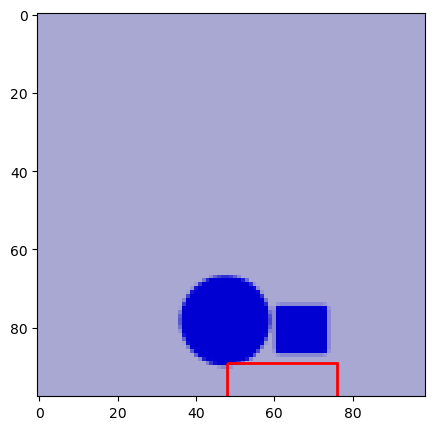

📌 Loaded shapes_1.png | Image Size: (98, 99) (Height, Width)
🛠 Input Box for SAM: [ 71  22 101  52]
✅ 3 masks detected.
🛠 Input Box for SAM: [14 13 50 49]
✅ 3 masks detected.


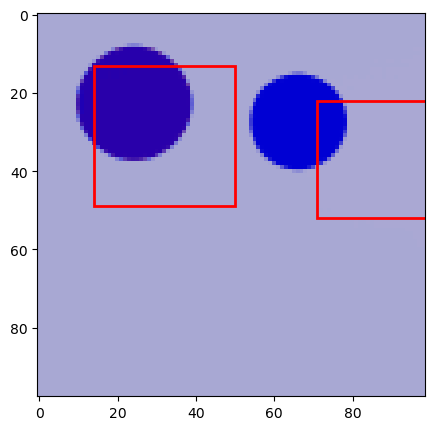

📌 Loaded shapes_2.png | Image Size: (98, 99) (Height, Width)
🛠 Input Box for SAM: [ 72  -6 118  40]
✅ 3 masks detected.
🛠 Input Box for SAM: [79 63 93 77]
✅ 3 masks detected.


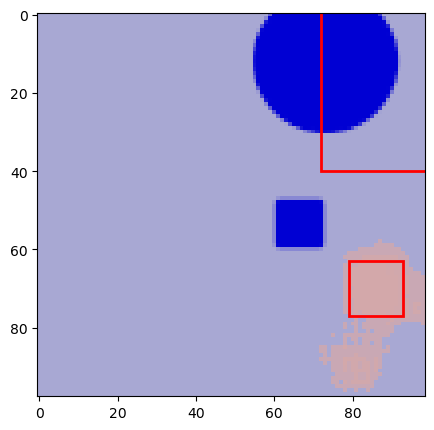

📌 Loaded shapes_3.png | Image Size: (98, 99) (Height, Width)
🛠 Input Box for SAM: [25 33 61 69]
✅ 3 masks detected.


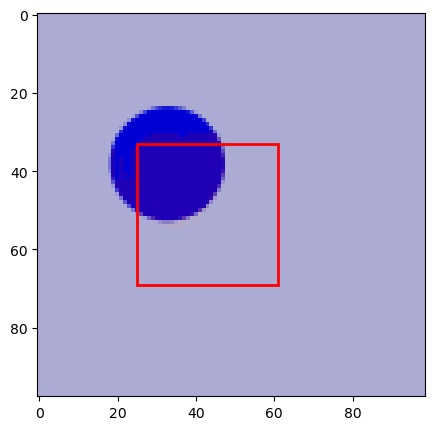

📌 Loaded shapes_4.png | Image Size: (98, 99) (Height, Width)
🛠 Input Box for SAM: [106  78 118  90]
✅ 3 masks detected.


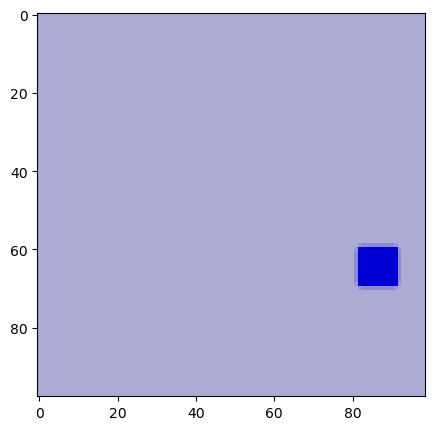


✅ SAM Masks Generated and Saved in COCO Format!
🔹 Total Images Processed: 5 | Masks Generated: 17 | No Masks: 0


In [14]:
#step3 trialss
import os
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model with Debugging
# ============================

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create directory if needed
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Download checkpoint if not exists
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

# Load SAM model
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations with Debugging
# ============================

DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_with_masks.json")

# Check if annotation file exists
if not os.path.exists(ANNOTATION_FILE):
    print(f"❌ ERROR: COCO annotation file not found: {ANNOTATION_FILE}")
    raise FileNotFoundError(f"COCO annotation file {ANNOTATION_FILE} does not exist!")

# Load COCO JSON
with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# Debug: Check if images exist
if len(coco_data["images"]) == 0:
    print("⚠️ WARNING: No images found in COCO annotations! Check dataset generation.")
    raise ValueError("COCO dataset has no images!")

# Debug: Check if annotations exist
if len(coco_data["annotations"]) == 0:
    print("⚠️ WARNING: No annotations found in COCO annotations! Expected bounding boxes.")
    raise ValueError("COCO dataset has no annotations!")

# ============================
# 🔹 Run SAM on Each Image & Generate Masks (with Normalization & Visualization)
# ============================

new_annotations = []
masks_generated = 0
no_masks_found = 0

# For final summary of results
image_summary = []

for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    # Check if image exists
    if not os.path.exists(img_path):
        print(f"⚠️ Skipping: {img_info['file_name']} (File Not Found)")
        continue

    # Load image
    image = cv2.imread(img_path)
    
    # Debugging: Print image size after loading
    original_img_width, original_img_height = image.shape[1], image.shape[0]
    print(f"📌 Loaded {img_info['file_name']} | Image Size: {image.shape[:2]} (Height, Width)")

    # Convert image to RGB for SAM model
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    # Initialize variables to track masks and image dimensions
    masks_detected_per_image = 0
    masks_generated_per_image = 0

    # Get annotations for the current image
    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]

    # Save before processing details for final summary
    image_summary.append({
        "image_name": img_info['file_name'],
        "before_processing_dimensions": (original_img_width, original_img_height),
        "bounding_boxes": [],
        "masks_detected": 0,
        "masks_generated": 0,
        "no_masks_found": 0
    })

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)

        # ✅ Normalize Bounding Box (0-1 scale)
        x_norm = x / original_img_width
        y_norm = y / original_img_height
        w_norm = w / original_img_width
        h_norm = h / original_img_height

        # ✅ Convert back to absolute pixel values
        x_scaled = int(x_norm * original_img_width)
        y_scaled = int(y_norm * original_img_height)
        w_scaled = int(w_norm * original_img_width)
        h_scaled = int(h_norm * original_img_height)

        # Adjusted Input Box for SAM
        input_box = np.array([x_scaled, y_scaled, x_scaled + w_scaled, y_scaled + h_scaled])

        # Debugging: Print bounding box details for SAM
        print(f"🛠 Input Box for SAM: {input_box}")

        # Run SAM for segmentation mask generation
        sam_masks, _, _ = predictor.predict(box=input_box)

        # Debugging: Check if SAM generated masks
        if len(sam_masks) == 0:
            print(f"⚠️ No masks found for {img_info['file_name']}! Skipping annotation.")
            no_masks_found += 1
            continue
        else:
            print(f"✅ {len(sam_masks)} masks detected.")
            masks_detected_per_image += len(sam_masks)

        # ✅ Draw Bounding Box
        rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        ax.add_patch(rect)

        # Normalize & Convert Mask to COCO Segmentation Format
        for mask in sam_masks:
            mask_indices = np.argwhere(mask)  # Get mask pixel positions
            mask_indices = mask_indices.astype(np.float32)  # Ensure float precision

            # ✅ Normalize the mask positions relative to the image size
            mask_indices[:, 0] /= original_img_height  # Normalize Y
            mask_indices[:, 1] /= original_img_width   # Normalize X

            # Scale back to pixel values for COCO format
            mask_indices[:, 0] *= original_img_height
            mask_indices[:, 1] *= original_img_width

            segmentation = mask_indices.flatten().tolist()

            # Convert mask to 0/1 binary format for better display
            mask = np.uint8(mask)  # Convert to uint8 (0 or 255 for black and white mask)
            
            # Display the mask with better contrast and transparency
            ax.imshow(mask, alpha=0.5, cmap="jet")  # Use 'jet' colormap or try 'hsv' for more contrast
            ax.imshow(image, alpha=0.5)  # Show original image with some transparency to overlay the mask

            # Save updated annotation with segmentation mask
            if segmentation:
                new_annotations.append({
                    "id": len(new_annotations) + 1,
                    "image_id": img_info["id"],
                    "category_id": ann["category_id"],
                    "segmentation": [segmentation],  # List of coordinates
                    "area": int(np.sum(mask)),  # Mask area
                    "bbox": ann["bbox"],  # Keep original bbox
                    "iscrowd": 0
                })
                masks_generated += 1
                masks_generated_per_image += 1

    plt.show()  # Show visualization per image

    image_summary[-1]["after_processing_dimensions"] = (original_img_width, original_img_height)
    image_summary[-1]["masks_detected"] = masks_detected_per_image
    image_summary[-1]["masks_generated"] = masks_generated_per_image
    image_summary[-1]["no_masks_found"] = no_masks_found

# ============================
# 🔹 Save Updated COCO Annotations
# ============================

# Update annotations in COCO JSON
coco_data["annotations"] = new_annotations

# Save updated COCO JSON
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

print("\n✅ SAM Masks Generated and Saved in COCO Format!")
print(f"🔹 Total Images Processed: {len(coco_data['images'])} | Masks Generated: {masks_generated} | No Masks: {no_masks_found}")

✅ Checkpoint already exists at: /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth
✅ Loaded COCO annotations from ./shapes_dataset/annotations/coco_annotations.json
🔹 Total Images: 5 | Total Annotations: 7
📌 Loaded shapes_0.png | Image Size: (98, 99) (Height, Width)


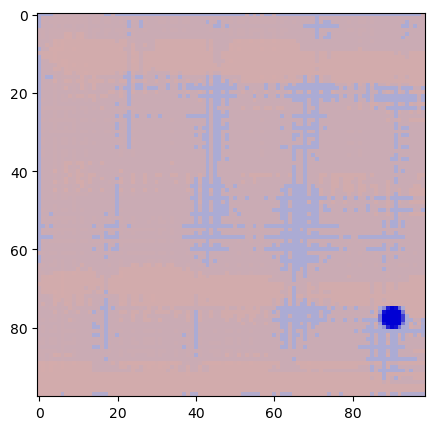

📌 Loaded shapes_1.png | Image Size: (98, 99) (Height, Width)


In [ ]:
#step 3 with IOU AND DICE
import os
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model with Debugging
# ============================

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create directory if needed
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Download checkpoint if not exists
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

# Load SAM model
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations with Debugging
# ============================

DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_with_masks.json")

# Check if annotation file exists
if not os.path.exists(ANNOTATION_FILE):
    print(f"❌ ERROR: COCO annotation file not found: {ANNOTATION_FILE}")
    raise FileNotFoundError(f"COCO annotation file {ANNOTATION_FILE} does not exist!")

# Load COCO JSON
with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# Debug: Check if images exist
if len(coco_data["images"]) == 0:
    print("⚠️ WARNING: No images found in COCO annotations! Check dataset generation.")
    raise ValueError("COCO dataset has no images!")

# Debug: Check if annotations exist
if len(coco_data["annotations"]) == 0:
    print("⚠️ WARNING: No annotations found in COCO annotations! Expected bounding boxes.")
    raise ValueError("COCO dataset has no annotations!")

# ============================
# 🔹 Run SAM on Each Image & Generate Masks (with Normalization & Visualization)
# ============================

# IoU and Dice Calculation
def calculate_metrics(predicted_mask, true_mask):
    """
    Calculate IoU and Dice score for the predicted and true binary masks.
    :param predicted_mask: The predicted segmentation mask (binary)
    :param true_mask: The ground truth segmentation mask (binary)
    :return: IoU and Dice score
    """
    predicted_mask = predicted_mask.flatten()
    true_mask = true_mask.flatten()
    # IoU (Intersection over Union)
    iou = np.sum(predicted_mask * true_mask) / np.sum(predicted_mask + true_mask - predicted_mask * true_mask)
    # Dice score (F1 score)
    dice = 2 * np.sum(predicted_mask * true_mask) / (np.sum(predicted_mask) + np.sum(true_mask))
    return iou, dice

new_annotations = []
masks_generated = 0
no_masks_found = 0

# For final summary of results
image_summary = []

for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    # Check if image exists
    if not os.path.exists(img_path):
        print(f"⚠️ Skipping: {img_info['file_name']} (File Not Found)")
        continue

    # Load image
    image = cv2.imread(img_path)
    original_img_width, original_img_height = image.shape[1], image.shape[0]
    print(f"📌 Loaded {img_info['file_name']} | Image Size: {image.shape[:2]} (Height, Width)")

    # Convert image to RGB for SAM model
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    # Initialize variables to track masks and image dimensions
    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    masks_detected_per_image = 0
    masks_generated_per_image = 0

    # Get annotations for the current image
    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]

    # Save before processing details for final summary
    image_summary.append({
        "image_name": img_info['file_name'],
        "before_processing_dimensions": (original_img_width, original_img_height),
        "bounding_boxes": [],
        "masks_detected": 0,
        "masks_generated": 0,
        "no_masks_found": 0,
        "iou": 0,  # IoU will be calculated for each image
        "dice": 0,  # Dice will be calculated for each image
    })

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    # True mask (generated from annotations) for IoU/Dice calculation
    true_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    for ann in img_annotations:
        x, y, w, h = map(int, ann["bbox"])
        cv2.rectangle(true_mask, (x, y), (x + w, y + h), 1, -1)

    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)

        # Normalize Bounding Box (0-1 scale)
        x_norm = x / original_img_width
        y_norm = y / original_img_height
        w_norm = w / original_img_width
        h_norm = h / original_img_height

        # Convert back to absolute pixel values
        x_scaled = int(x_norm * original_img_width)
        y_scaled = int(y_norm * original_img_height)
        w_scaled = int(w_norm * original_img_width)
        h_scaled = int(h_norm * original_img_height)

        # Adjusted Input Box for SAM
        input_box = np.array([x_scaled, y_scaled, x_scaled + w_scaled, y_scaled + h_scaled])

        # Run SAM for segmentation mask generation
        sam_masks, _, _ = predictor.predict(box=input_box)

        if len(sam_masks) == 0:
            print(f"⚠️ No masks found for {img_info['file_name']}! Skipping annotation.")
            no_masks_found += 1
            continue
        else:
            masks_detected_per_image += len(sam_masks)

        # Draw Bounding Box
        rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        ax.add_patch(rect)

        for mask in sam_masks:
            mask_indices = np.argwhere(mask)
            mask_indices = mask_indices.astype(np.float32)
            mask_indices[:, 0] /= original_img_height
            mask_indices[:, 1] /= original_img_width
            mask_indices[:, 0] *= original_img_height
            mask_indices[:, 1] *= original_img_width
            segmentation = mask_indices.flatten().tolist()

            # Convert mask to 0/1 binary format for better display
            mask = np.uint8(mask)
            ax.imshow(mask, alpha=0.5, cmap="jet")
            ax.imshow(image, alpha=0.5)

            if segmentation:
                new_annotations.append({
                    "id": len(new_annotations) + 1,
                    "image_id": img_info["id"],
                    "category_id": ann["category_id"],
                    "segmentation": [segmentation],
                    "area": int(np.sum(mask)),
                    "bbox": ann["bbox"],
                    "iscrowd": 0
                })
                masks_generated += 1
                masks_generated_per_image += 1

                # IoU and Dice calculation for each mask
                iou, dice = calculate_metrics(mask, true_mask)
                image_summary[-1]["iou"] = iou
                image_summary[-1]["dice"] = dice

    plt.show()

    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    image_summary[-1]["after_processing_dimensions"] = (processed_img_width, processed_img_height)
    image_summary[-1]["masks_detected"] = masks_detected_per_image
    image_summary[-1]["masks_generated"] = masks_generated_per_image
    image_summary[-1]["no_masks_found"] = no_masks_found

# Save updated COCO annotations
coco_data["annotations"] = new_annotations
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

print("\n✅ SAM Masks Generated and Saved in COCO Format!")

In [15]:
# Step 4: Verify Updated COCO Annotations
# Load updated COCO annotations
with open(OUTPUT_ANNOTATION_FILE, "r") as f:
    updated_coco_data = json.load(f)
# Debugging: Loop over annotations and extract bounding boxes
for ann in coco_data["annotations"]:
    x, y, w, h = map(int, ann["bbox"])  # Extract coordinates and size
    print(f"🖼 Object | BBox: ({x}, {y}, {x+w}, {y+h}) | Size: ({w}x{h})")

# Check if segmentation is now included
sample_ann = next((ann for ann in updated_coco_data["annotations"] if "segmentation" in ann), None)

if sample_ann:
    print("✅ Segmentation Data Found in COCO Format!")
    print(json.dumps(sample_ann, indent=4))
else:
    print("❌ ERROR: No segmentation data found. Ensure SAM generated masks correctly!")


🖼 Object | BBox: (48, 89, 76, 117) | Size: (28x28)
🖼 Object | BBox: (71, 22, 101, 52) | Size: (30x30)
🖼 Object | BBox: (71, 22, 101, 52) | Size: (30x30)
🖼 Object | BBox: (71, 22, 101, 52) | Size: (30x30)
🖼 Object | BBox: (14, 13, 50, 49) | Size: (36x36)
🖼 Object | BBox: (14, 13, 50, 49) | Size: (36x36)
🖼 Object | BBox: (14, 13, 50, 49) | Size: (36x36)
🖼 Object | BBox: (72, -6, 118, 40) | Size: (46x46)
🖼 Object | BBox: (72, -6, 118, 40) | Size: (46x46)
🖼 Object | BBox: (79, 63, 93, 77) | Size: (14x14)
🖼 Object | BBox: (79, 63, 93, 77) | Size: (14x14)
🖼 Object | BBox: (79, 63, 93, 77) | Size: (14x14)
🖼 Object | BBox: (25, 33, 61, 69) | Size: (36x36)
🖼 Object | BBox: (25, 33, 61, 69) | Size: (36x36)
🖼 Object | BBox: (25, 33, 61, 69) | Size: (36x36)
🖼 Object | BBox: (106, 78, 118, 90) | Size: (12x12)
🖼 Object | BBox: (106, 78, 118, 90) | Size: (12x12)
✅ Segmentation Data Found in COCO Format!
{
    "id": 1,
    "image_id": 0,
    "category_id": 1,
    "segmentation": [
        [
          

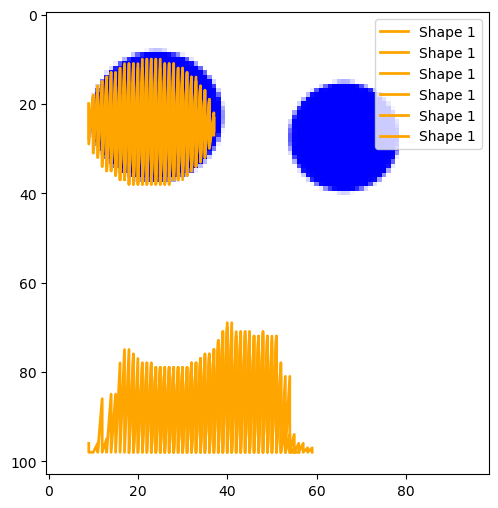

In [16]:
# Step 5: Visualize the Segmentation Masks
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Define the directory where your images are stored
image_dir = "./shapes_dataset/images"  # Adjust this path as necessary

# Define custom colors for each category
category_colors = {
    1: 'orange',   # Category 1 (e.g., "circle")
    2: 'pink',  # Category 2 (e.g., "rectangle")
}

# Pick a random image
image_id = np.random.choice(len(updated_coco_data["images"]))
image_info = updated_coco_data["images"][image_id]
image_path = os.path.join(image_dir, image_info["file_name"])

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image)

# Iterate through annotations and plot the segmentation masks with appropriate colors
for ann in updated_coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        for seg in ann["segmentation"]:
            poly = np.array(seg).reshape(-1, 2)
            # Get the color for the category, default to 'gray' if not found
            color = category_colors.get(ann['category_id'], 'gray')  
            ax.plot(poly[:, 0], poly[:, 1], linewidth=2, label=f"Shape {ann['category_id']}", color=color)

# Display the legend
ax.legend()

# Show the plot
plt.show()

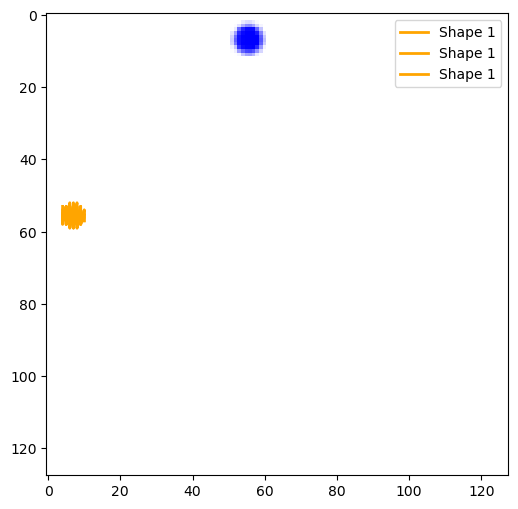


IoU and Dice Summary per Image:
          Image       IoU      Dice
0  shapes_0.png  0.474359  0.643478
1  shapes_1.png  0.637931  0.778947
2  shapes_2.png  0.411765  0.583333
3  shapes_3.png  0.390476  0.561644
4  shapes_4.png  0.451220  0.621849


In [94]:
#step 5 WITH IOU AND DICE
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import pandas as pd

# Define the directory where your images are stored
image_dir = "./shapes_dataset/images"  # Adjust this path as necessary

# Define custom colors for each category
category_colors = {
    1: 'orange',   # Category 1 (e.g., "circle")
    2: 'pink',  # Category 2 (e.g., "rectangle")
}

# Pick a random image
image_id = np.random.choice(len(updated_coco_data["images"]))
image_info = updated_coco_data["images"][image_id]
image_path = os.path.join(image_dir, image_info["file_name"])

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Load segmentation masks
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image)

# Iterate through annotations and plot the segmentation masks
for ann in updated_coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        for seg in ann["segmentation"]:
            poly = np.array(seg).reshape(-1, 2)
            color = category_colors.get(ann['category_id'], 'gray')  
            ax.plot(poly[:, 0], poly[:, 1], linewidth=2, label=f"Shape {ann['category_id']}", color=color)

# Display the legend
ax.legend()
plt.show()

# Display IoU and Dice for each image
iou_dice_summary = []
for img_info in image_summary:
    iou_dice_summary.append({
        "Image": img_info["image_name"],
        "IoU": img_info["iou"],
        "Dice": img_info["dice"]
    })

# Create a DataFrame for a cleaner table
df = pd.DataFrame(iou_dice_summary)
print("\nIoU and Dice Summary per Image:")
print(df)

In [ ]:
"""
This script processes a dataset for image segmentation, using the Segment Anything Model (SAM) for generating masks and calculating performance metrics (IoU and Dice) for each epoch.

Steps:

1. **Dataset Generation (Step 1)**:
    - The dataset is generated using a pre-existing script (`shapes/run.py`).
    - The number of images and their dimensions (width and height) are dynamically set by the user.
    - The dataset is created in COCO format and saved at the specified directory (`shapes_dataset`).
    - The script checks if the dataset was created correctly, ensuring the presence of the COCO annotation file.

2. **Load and Verify COCO Annotations (Step 2)**:
    - The script loads the COCO annotations from the generated dataset (`coco_annotations.json`).
    - It verifies that the annotations and images are loaded properly by inspecting the dataset structure and printing basic details.
    - The bounding boxes of the objects in the dataset are also printed for debugging.

3. **Load SAM Model and Setup (Step 3)**:
    - The SAM model (`vit_h`) is loaded from a specified checkpoint.
    - The model's weights are downloaded if they don't already exist at the specified location.
    - The SAM model is then set up using the `SamPredictor` for mask prediction on input images.

4. **Run SAM on Each Image & Generate Masks with IoU and Dice Calculation (Step 4)**:
    - The script processes each image from the COCO dataset, loading each image one by one.
    - Bounding boxes from the annotations are used to guide SAM's segmentation mask prediction.
    - Each image is passed through SAM for mask generation, and the generated masks are drawn over the image.
    - **IoU and Dice**: For each mask generated by SAM, IoU (Intersection over Union) and Dice scores (F1 score) are calculated based on the true mask from the annotations.
    - These metrics are accumulated for each image and averaged for the entire dataset per epoch.

5. **Visualize Segmentation and Metrics (Step 5)**:
    - After processing each image, the segmentation result (image with overlayed mask) is displayed.
    - The metrics (IoU and Dice) for each image are displayed in a table at the end of each epoch.
    - At the end of all epochs, a summary of IoU and Dice scores for each image is shown, indicating the model's segmentation performance.

6. **Final Summary and COCO Annotation Update**:
    - After all images are processed, the updated annotations (including the segmentation masks generated by SAM) are saved in a new JSON file (`coco_annotations_with_masks.json`).
    - The final summary includes the number of masks detected, the number of masks generated, and the number of images processed.
    - It also includes the final performance metrics (IoU and Dice) for each image after all epochs.

This script runs for a user-defined number of epochs, providing automatic evaluation of segmentation performance after each epoch, and visualizes the segmentation performance for each image.
"""


✅ Shapes dataset successfully generated with 5 images of size 128x128!
🖼 Object | BBox: (47, 28, 51, 32) | Size: (4x4)
🖼 Object | BBox: (70, 46, 76, 52) | Size: (6x6)
🖼 Object | BBox: (53, 5, 59, 11) | Size: (6x6)
🖼 Object | BBox: (50, 84, 56, 90) | Size: (6x6)
🖼 Object | BBox: (83, 119, 89, 125) | Size: (6x6)
🖼 Object | BBox: (93, 17, 99, 23) | Size: (6x6)
🖼 Object | BBox: (120, 106, 126, 112) | Size: (6x6)
🖼 Object | BBox: (74, 76, 78, 80) | Size: (4x4)
🖼 Object | BBox: (40, 39, 46, 45) | Size: (6x6)
✅ COCO Annotations Loaded Successfully!
{
    "images": [
        {
            "id": 0,
            "width": 128,
            "height": 128,
            "file_name": "shapes_0.png"
        },
        {
            "id": 1,
            "width": 128,
            "height": 128,
            "file_name": "shapes_1.png"
        },
        {
            "id": 2,
            "width": 128,
            "height": 128,
            "file_name": "shapes_2.png"
        },
        {
            "id": 

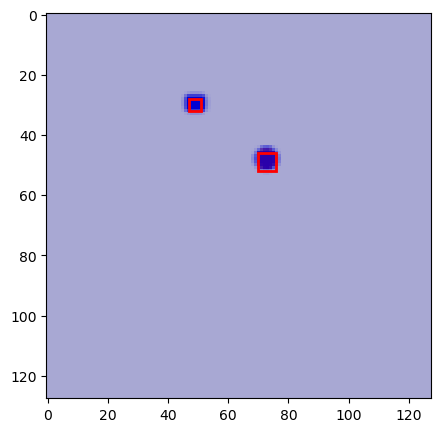

📌 Loaded shapes_1.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.


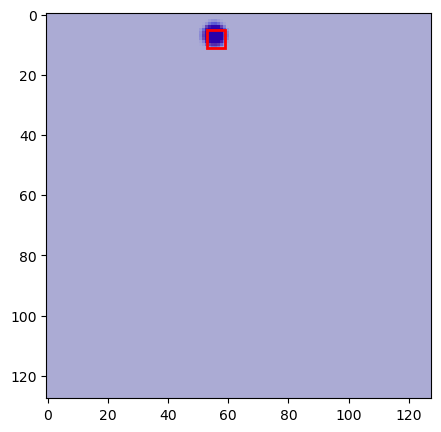

📌 Loaded shapes_2.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


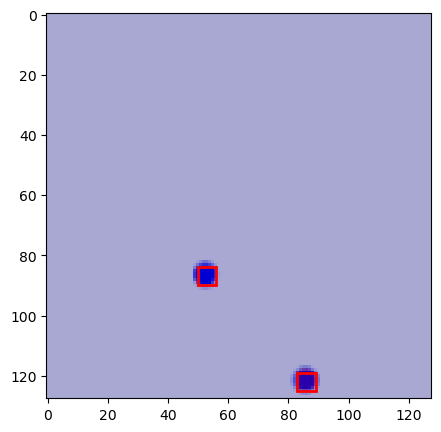

📌 Loaded shapes_3.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


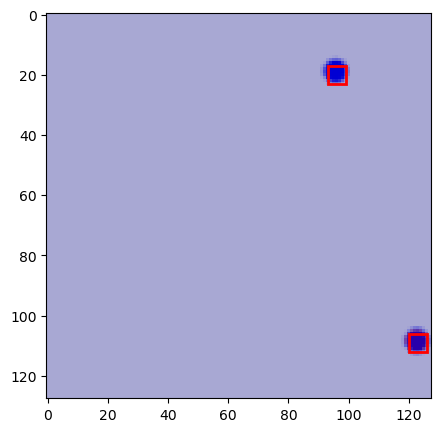

📌 Loaded shapes_4.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


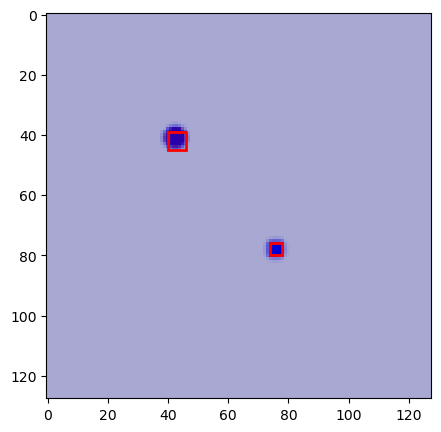

Epoch 2/5
📌 Loaded shapes_0.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


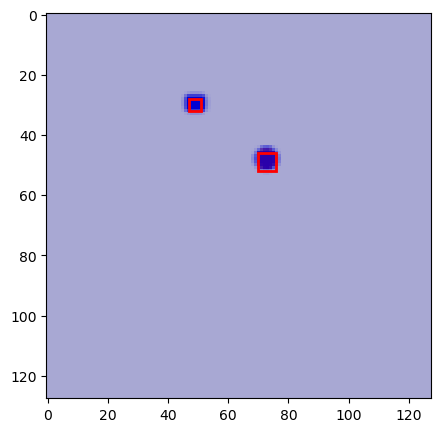

📌 Loaded shapes_1.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.


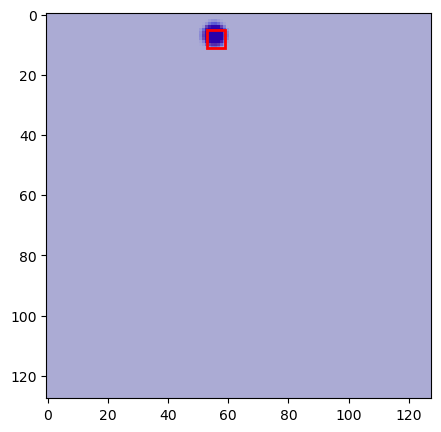

📌 Loaded shapes_2.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


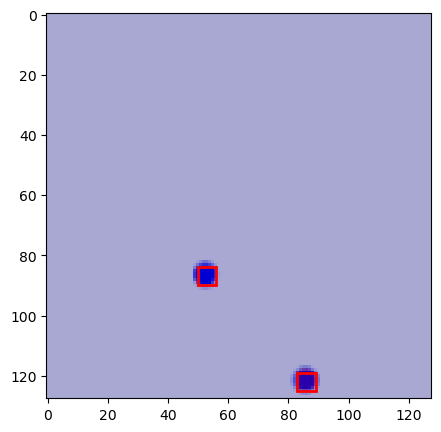

📌 Loaded shapes_3.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


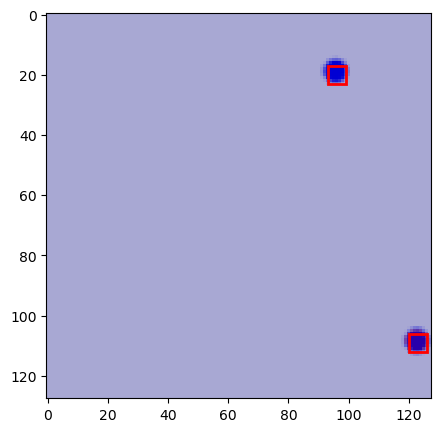

📌 Loaded shapes_4.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


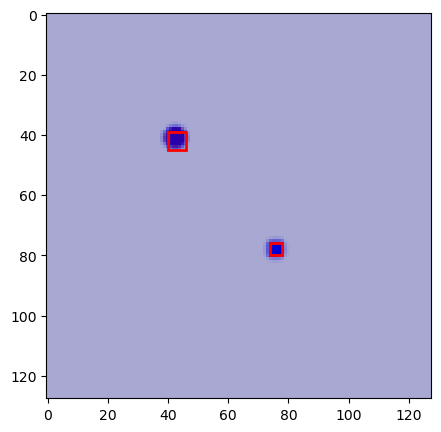

Epoch 3/5
📌 Loaded shapes_0.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


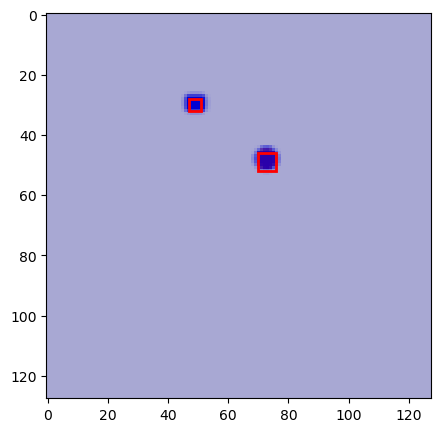

📌 Loaded shapes_1.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.


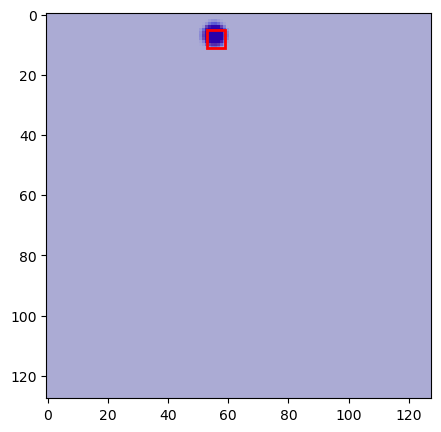

📌 Loaded shapes_2.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


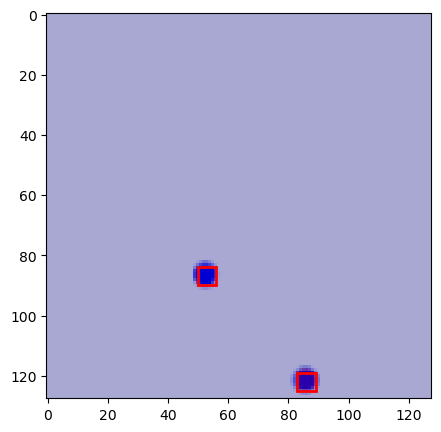

📌 Loaded shapes_3.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


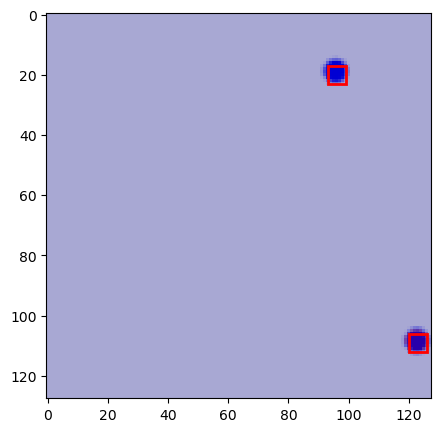

📌 Loaded shapes_4.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


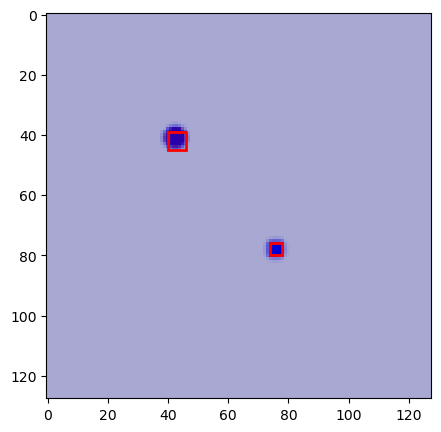

Epoch 4/5
📌 Loaded shapes_0.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


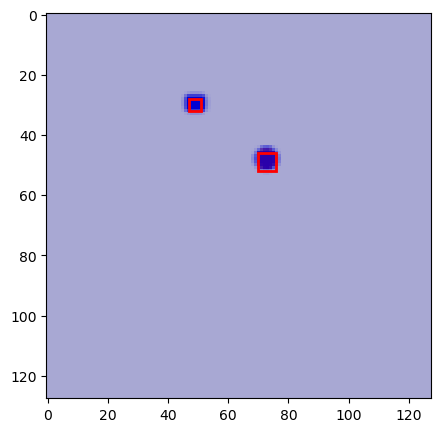

📌 Loaded shapes_1.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.


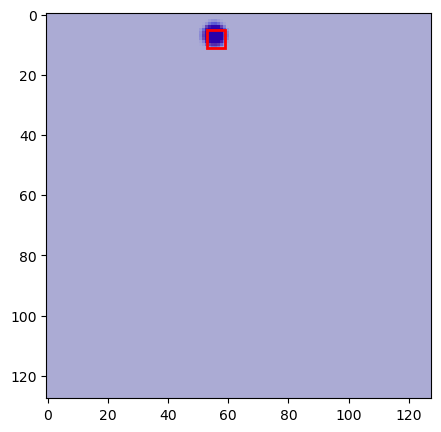

📌 Loaded shapes_2.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


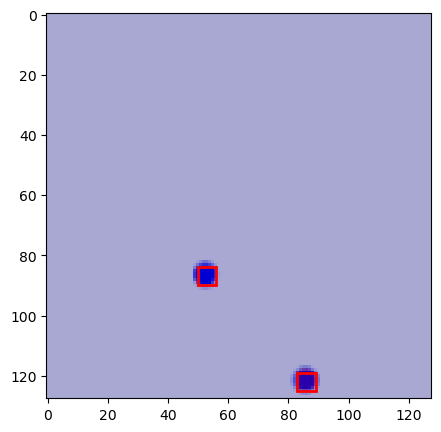

📌 Loaded shapes_3.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


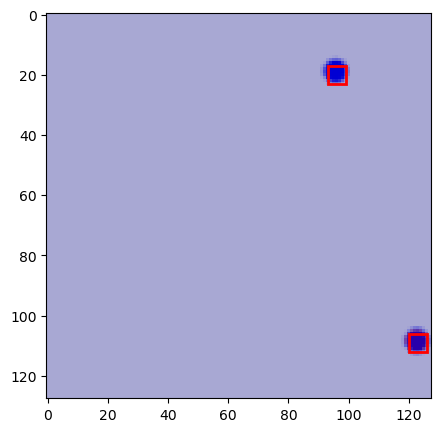

📌 Loaded shapes_4.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


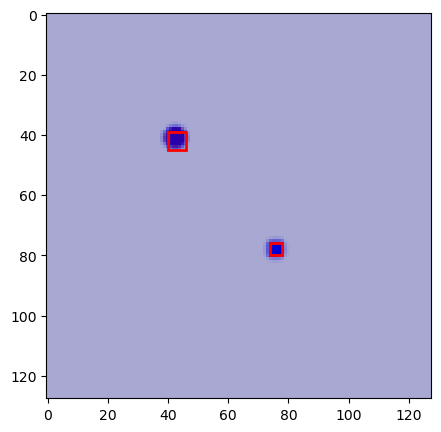

Epoch 5/5
📌 Loaded shapes_0.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


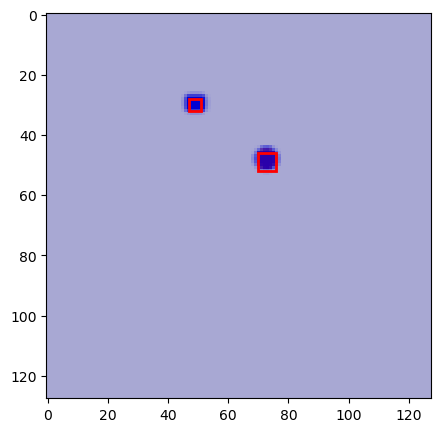

📌 Loaded shapes_1.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.


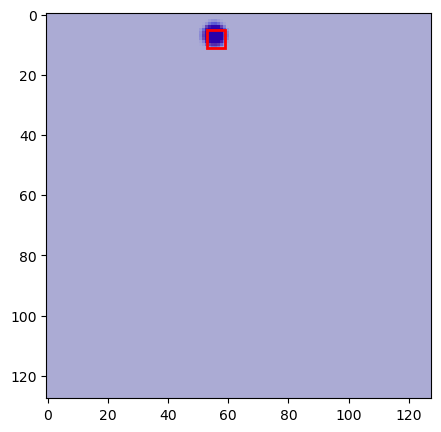

📌 Loaded shapes_2.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


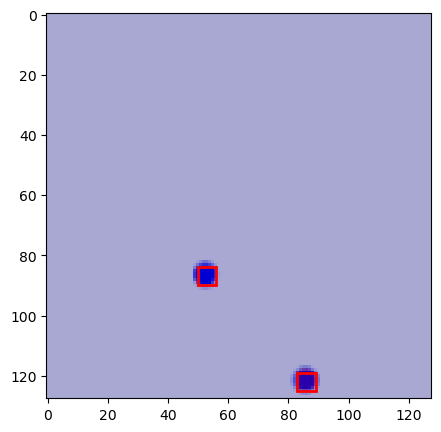

📌 Loaded shapes_3.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


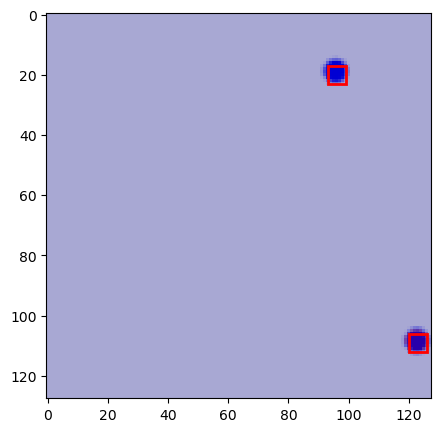

📌 Loaded shapes_4.png | Image Size: (128, 128) (Height, Width)
✅ 3 masks detected.
✅ 3 masks detected.


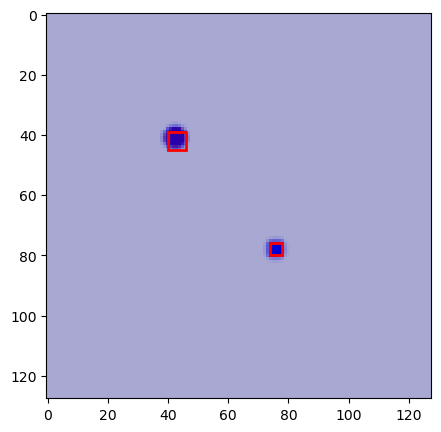


✅ SAM Masks Generated and Saved in COCO Format!
🔹 Total Images Processed: 5 | Masks Generated: 135 | No Masks: 0

🔹 Full Summary of Results:

📌 shapes_0.png - IoU: 0.4744 | Dice: 0.6435

📌 shapes_1.png - IoU: 0.6379 | Dice: 0.7789

📌 shapes_2.png - IoU: 0.4118 | Dice: 0.5833

📌 shapes_3.png - IoU: 0.3905 | Dice: 0.5616

📌 shapes_4.png - IoU: 0.4512 | Dice: 0.6218

📌 shapes_0.png - IoU: 0.4744 | Dice: 0.6435

📌 shapes_1.png - IoU: 0.6379 | Dice: 0.7789

📌 shapes_2.png - IoU: 0.4118 | Dice: 0.5833

📌 shapes_3.png - IoU: 0.3905 | Dice: 0.5616

📌 shapes_4.png - IoU: 0.4512 | Dice: 0.6218

📌 shapes_0.png - IoU: 0.4744 | Dice: 0.6435

📌 shapes_1.png - IoU: 0.6379 | Dice: 0.7789

📌 shapes_2.png - IoU: 0.4118 | Dice: 0.5833

📌 shapes_3.png - IoU: 0.3905 | Dice: 0.5616

📌 shapes_4.png - IoU: 0.4512 | Dice: 0.6218

📌 shapes_0.png - IoU: 0.4744 | Dice: 0.6435

📌 shapes_1.png - IoU: 0.6379 | Dice: 0.7789

📌 shapes_2.png - IoU: 0.4118 | Dice: 0.5833

📌 shapes_3.png - IoU: 0.3905 | Dice: 0.5616

📌 

In [158]:
import subprocess
import os
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
from sklearn.metrics import jaccard_score, f1_score
import pandas as pd

# ============================
# Step 1: Generate Shapes Dataset (Ensures COCO Format)
# ============================
dataset_path = "./shapes_dataset"
num_images = 5
image_width = 128
image_height = 128

# Run the dataset generation script inside Jupyter
command = [
    "python", "shapes/run.py",
    "--save_dir", dataset_path,
    "--num_images", str(num_images),
    "--image_size", str(image_width), str(image_height), 
    "--task_type", "segmentation"
]

# Execute the command
result = subprocess.run(command, capture_output=True, text=True)
print(result.stdout)

if not os.path.exists(f"{dataset_path}/annotations/coco_annotations.json"):
    print("❌ ERROR: Dataset not generated correctly! Check run.py.")
else:
    print(f"✅ Shapes dataset successfully generated with {num_images} images of size {image_width}x{image_height}!")

# ============================
# Step 2: Load and Verify COCO Annotations
# ============================
OUTPUT_ANNOTATION_FILE = "./shapes_dataset/annotations/coco_annotations.json"

# Verify COCO Annotations
try:
    with open(OUTPUT_ANNOTATION_FILE, "r") as f:
        coco_data = json.load(f)
        # Debugging: Loop over annotations and extract bounding boxes
    for ann in coco_data["annotations"]:
        x, y, w, h = map(int, ann["bbox"])
        print(f"🖼 Object | BBox: ({x}, {y}, {x+w}, {y+h}) | Size: ({w}x{h})")
    print("✅ COCO Annotations Loaded Successfully!")
    print(json.dumps(coco_data, indent=4)[:1000])  # Print first 1000 characters

except FileNotFoundError:
    print(f"❌ ERROR: The file {OUTPUT_ANNOTATION_FILE} was not found. Make sure it was generated correctly!")

# ============================
# Step 3: Load SAM Model & Process COCO Annotations with Visualization
# ============================

# 🔹 Load SAM Model
CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "./weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

os.makedirs(WEIGHTS_DIR, exist_ok=True)

if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# Load COCO Annotations
DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")

with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# ============================
# Step 4: Calculate IoU and Dice Scores
# ============================
def calculate_metrics(predicted_mask, true_mask):
    predicted_mask = predicted_mask.flatten()
    true_mask = true_mask.flatten()
    iou = np.sum(predicted_mask * true_mask) / np.sum(predicted_mask + true_mask - predicted_mask * true_mask)
    dice = 2 * np.sum(predicted_mask * true_mask) / (np.sum(predicted_mask) + np.sum(true_mask))
    return iou, dice

# ============================
# Step 5: Run SAM on Each Image & Visualize
# ============================
image_summary = []
new_annotations = []
masks_generated = 0
no_masks_found = 0

category_colors = {
    1: 'orange',   # Category 1 (e.g., "circle")
    2: 'pink',      # Category 2 (e.g., "rectangle")
}

# Process each image sequentially
for epoch in range(1, 6):  # Change the range for different epochs
    print(f"Epoch {epoch}/5")
    for img_idx, img_info in enumerate(coco_data["images"]):  # Process image in order (0,1,2,...)
        img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

        if not os.path.exists(img_path):
            print(f"⚠️ Skipping: {img_info['file_name']} (File Not Found)")
            continue

        image = cv2.imread(img_path)
        original_img_width, original_img_height = image.shape[1], image.shape[0]
        print(f"📌 Loaded {img_info['file_name']} | Image Size: {image.shape[:2]} (Height, Width)")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        predictor.set_image(image)

        # Initialize variables for masks
        masks_detected_per_image = 0
        masks_generated_per_image = 0

        # Get annotations for the current image
        img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]

        image_summary.append({
            "image_name": img_info['file_name'],
            "masks_detected": 0,
            "masks_generated": 0,
            "no_masks_found": 0,
            "iou": 0,  # IoU will be calculated per image
            "dice": 0,  # Dice will be calculated per image
        })

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(image)

        # Ground truth mask from annotations for IoU/Dice calculation
        true_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        for ann in img_annotations:
            x, y, w, h = map(int, ann["bbox"])
            cv2.rectangle(true_mask, (x, y), (x + w, y + h), 1, -1)

        for ann in img_annotations:
            bbox = ann["bbox"]
            x, y, w, h = map(int, bbox)

            # Normalize Bounding Box (0-1 scale)
            x_norm = x / original_img_width
            y_norm = y / original_img_height
            w_norm = w / original_img_width
            h_norm = h / original_img_height

            # Convert back to absolute pixel values
            x_scaled = int(x_norm * original_img_width)
            y_scaled = int(y_norm * original_img_height)
            w_scaled = int(w_norm * original_img_width)
            h_scaled = int(h_norm * original_img_height)

            # Adjusted Input Box for SAM
            input_box = np.array([x_scaled, y_scaled, x_scaled + w_scaled, y_scaled + h_scaled])

            # Run SAM for segmentation mask generation
            sam_masks, _, _ = predictor.predict(box=input_box)

            if len(sam_masks) == 0:
                print(f"⚠️ No masks found for {img_info['file_name']}! Skipping annotation.")
                no_masks_found += 1
                continue
            else:
                print(f"✅ {len(sam_masks)} masks detected.")
                masks_detected_per_image += len(sam_masks)

            # Draw Bounding Box
            rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
            ax.add_patch(rect)

            for mask in sam_masks:
                mask_indices = np.argwhere(mask)
                mask_indices = mask_indices.astype(np.float32)
                mask_indices[:, 0] /= original_img_height  # Normalize Y
                mask_indices[:, 1] /= original_img_width   # Normalize X

                # Scale back to pixel values for COCO format
                mask_indices[:, 0] *= original_img_height
                mask_indices[:, 1] *= original_img_width

                segmentation = mask_indices.flatten().tolist()

                # Convert mask to 0/1 binary format for better display
                mask = np.uint8(mask)  # Convert to uint8 (0 or 255 for black and white mask)
                
                # Show the mask with transparency over the image
                ax.imshow(mask, alpha=0.5, cmap="jet")
                ax.imshow(image, alpha=0.5)

                if segmentation:
                    new_annotations.append({
                        "id": len(new_annotations) + 1,
                        "image_id": img_info["id"],
                        "category_id": ann["category_id"],
                        "segmentation": [segmentation],
                        "area": int(np.sum(mask)),
                        "bbox": ann["bbox"],
                        "iscrowd": 0
                    })
                    masks_generated += 1
                    masks_generated_per_image += 1

                    # IoU and Dice calculation for each mask
                    iou, dice = calculate_metrics(mask, true_mask)
                    image_summary[-1]["iou"] = iou
                    image_summary[-1]["dice"] = dice

        # Show visualization per image
        plt.show()

        # Save processed image details for final summary
        image_summary[-1]["masks_detected"] = masks_detected_per_image
        image_summary[-1]["masks_generated"] = masks_generated_per_image
        image_summary[-1]["no_masks_found"] = no_masks_found

# Save updated COCO annotations
coco_data["annotations"] = new_annotations
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

# Debugging Summary After Processing All Images
print("\n✅ SAM Masks Generated and Saved in COCO Format!")
print(f"🔹 Total Images Processed: {len(coco_data['images'])} | Masks Generated: {masks_generated} | No Masks: {no_masks_found}")

# Final Full Summary of Results
print("\n🔹 Full Summary of Results:")
for img_info in image_summary:
    print(f"\n📌 {img_info['image_name']} - IoU: {img_info['iou']:.4f} | Dice: {img_info['dice']:.4f}")